In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aliiihussain/e-commerce-data-analyst/ecommerce_sales_data.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/aliiihussain/e-commerce-data-analyst/ecommerce_sales_data.csv")

In [3]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [5]:
df.shape

(3500, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


In [7]:
df.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Order Date']=pd.to_datetime(df['Order Date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3500 non-null   datetime64[ns]
 1   Product Name  3500 non-null   object        
 2   Category      3500 non-null   object        
 3   Region        3500 non-null   object        
 4   Quantity      3500 non-null   int64         
 5   Sales         3500 non-null   int64         
 6   Profit        3500 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 191.5+ KB


In [11]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [12]:
df['Product Name'].nunique()

10

In [14]:
df['Product Name'].unique()

array(['Printer', 'Mouse', 'Tablet', 'Camera', 'Headphones', 'Smartwatch',
       'Monitor', 'Smartphone', 'Keyboard', 'Laptop'], dtype=object)

In [32]:
result=df.groupby('Product Name').agg(
    Total_sales=('Sales', 'sum'),
    Total_profit=('Profit', 'sum'),
    Total_quantity=('Quantity', 'sum')
)

In [33]:
result.sort_values(by="Total_profit",ascending=False)

,Total_sales,Total_profit,Total_quantity
Product Name,,,
Camera,1177381,207630.99,1795
Monitor,1160048,202028.17,1876
Mouse,1074398,185763.69,1753
Laptop,1005873,185756.81,1658
Printer,1094216,185394.88,1734
Smartphone,1069681,183296.97,1617
Smartwatch,1049211,178995.81,1807
Keyboard,1024507,175814.68,1684
Headphones,988638,172478.20,1604


In [34]:
result['Profit_margin'] = result['Total_profit'] / result['Total_sales']

In [36]:
result

,Total_sales,Total_profit,Total_quantity,Profit_margin
Product Name,,,,
Camera,1177381,207630.99,1795,0.176350
Headphones,988638,172478.20,1604,0.174460
Keyboard,1024507,175814.68,1684,0.171609
Laptop,1005873,185756.81,1658,0.184672
Monitor,1160048,202028.17,1876,0.174155
Mouse,1074398,185763.69,1753,0.172900
Printer,1094216,185394.88,1734,0.169432
Smartphone,1069681,183296.97,1617,0.171357
Smartwatch,1049211,178995.81,1807,0.170600


In [35]:
result.sort_values(by='Profit_margin', ascending=False)

,Total_sales,Total_profit,Total_quantity,Profit_margin
Product Name,,,,
Laptop,1005873,185756.81,1658,0.184672
Camera,1177381,207630.99,1795,0.176350
Headphones,988638,172478.20,1604,0.174460
Monitor,1160048,202028.17,1876,0.174155
Mouse,1074398,185763.69,1753,0.172900
Keyboard,1024507,175814.68,1684,0.171609
Smartphone,1069681,183296.97,1617,0.171357
Smartwatch,1049211,178995.81,1807,0.170600
Printer,1094216,185394.88,1734,0.169432


In [40]:
result['Profit_per_unit']=result['Total_profit']/result['Total_quantity']

In [41]:
result

,Total_sales,Total_profit,Total_quantity,Profit_margin,Profit_per_sale,Profit_per_unit
Product Name,,,,,,
Camera,1177381,207630.99,1795,0.176350,115.671861,115.671861
Headphones,988638,172478.20,1604,0.174460,107.530050,107.530050
Keyboard,1024507,175814.68,1684,0.171609,104.403017,104.403017
Laptop,1005873,185756.81,1658,0.184672,112.036677,112.036677
Monitor,1160048,202028.17,1876,0.174155,107.690922,107.690922
Mouse,1074398,185763.69,1753,0.172900,105.969019,105.969019
Printer,1094216,185394.88,1734,0.169432,106.917463,106.917463
Smartphone,1069681,183296.97,1617,0.171357,113.356197,113.356197
Smartwatch,1049211,178995.81,1807,0.170600,99.056895,99.056895


In [42]:
result_1=df.groupby(['Product Name', 'Region']).agg(
    Total_sales=('Sales', 'sum'),
    Total_profit=('Profit', 'sum'),
    Total_quantity=('Quantity', 'sum')
)

In [43]:
result_1

Total_sales  Total_profit  Total_quantity
Product Name Region                                           
Camera       East         261786      44880.72             410
             North        281561      51539.92             415
             South        331476      61837.30             527
             West         302558      49373.05             443
Headphones   East         251700      44253.62             386
             North        198684      35271.58             386
             South        292675      48918.52             472
             West         245579      44034.48             360
Keyboard     East         289877      49035.88             469
             North        251399      42854.25             427
             South        247648      43399.78             427
             West         235583      40524.77             361
Laptop       East         280147      49799.67             452
             North        245796      47233.50             414
             South        207327      38417.23             384
             West         272603      50306.41             408
Monitor      East         256596      41722.84             424
             North        306624      52481.85             504
             South        262849      45625.39             448
             West         333979      62198.09             500
Mouse        East         234142      42827.57             393
             North        263934      41545.73             387
             South        273496      49179.68             475
             West         302826      52210.71             498
Printer      East         265584      47388.14             379
             North        223430      32575.35             376
             South        337353      56246.79             500
             West         267849      49184.60             479
Smartphone   East         297276      55295.27             469
             North        225551      33808.95             346
             South        213148      34996.69             327
             West         333706      59196.06             475
Smartwatch   East         284816      45924.55             517
             North        249044      46774.73             444
             South        240224      40307.50             390
             West         275127      45989.03             456
Tablet       East         253186      43760.20             407
             North        242750      42228.89             407
             South        253352      39174.39             411
             West         274640      42341.53             508

In [50]:
result_2=df.groupby('Region').agg(
     Total_sales=('Sales', 'sum'),
    Total_profit=('Profit', 'sum'),
    Total_quantity=('Quantity', 'sum')
)

In [45]:
result_2

,Total_sales,Total_profit,Total_quantity
Region,,,
East,2675110,464888.46,4306
North,2488773,426314.75,4106
South,2659548,458103.27,4361
West,2844450,495358.73,4488


In [46]:
result_2['Profit_margin']=result_2['Total_profit']/result_2['Total_sales']

In [47]:
result_2

,Total_sales,Total_profit,Total_quantity,Profit_margin
Region,,,,
East,2675110,464888.46,4306,0.173783
North,2488773,426314.75,4106,0.171295
South,2659548,458103.27,4361,0.172249
West,2844450,495358.73,4488,0.174149


In [53]:
result_west=df[df['Region']=='West'].groupby('Product Name').agg( Total_sales=('Sales', 'sum'),
    Total_profit=('Profit', 'sum'),
    Total_quantity=('Quantity', 'sum'))

In [54]:
result_west['Profit_margin']=result_west['Total_profit']/result_west['Total_sales']

In [55]:
result_west

,Total_sales,Total_profit,Total_quantity,Profit_margin
Product Name,,,,
Camera,302558,49373.05,443,0.163185
Headphones,245579,44034.48,360,0.179309
Keyboard,235583,40524.77,361,0.172019
Laptop,272603,50306.41,408,0.184541
Monitor,333979,62198.09,500,0.186234
Mouse,302826,52210.71,498,0.172412
Printer,267849,49184.60,479,0.183628
Smartphone,333706,59196.06,475,0.177390
Smartwatch,275127,45989.03,456,0.167156


In [56]:
result_west.sort_values(by='Total_quantity',ascending=False).head(3)

,Total_sales,Total_profit,Total_quantity,Profit_margin
Product Name,,,,
Tablet,274640,42341.53,508,0.154171
Monitor,333979,62198.09,500,0.186234
Mouse,302826,52210.71,498,0.172412


In [60]:
result_camera=df[df['Product Name']=='Camera'].groupby('Region').agg( 
    Total_sales=('Sales', 'sum'),
    Total_profit=('Profit', 'sum'),
    Total_quantity=('Quantity', 'sum'))

In [61]:
result_camera['Profit_margin']=result_camera['Total_profit']/result_camera['Total_sales']

In [62]:
result_camera

,Total_sales,Total_profit,Total_quantity,Profit_margin
Region,,,,
East,261786,44880.72,410,0.171440
North,281561,51539.92,415,0.183051
South,331476,61837.30,527,0.186551
West,302558,49373.05,443,0.163185


In [63]:
result_1['Profit_per_unit']=result_1['Total_profit']/result_1['Total_quantity']

In [64]:
result_1['Profit_margin']=result_1['Total_profit']/result_1['Total_sales']

In [65]:
result_1

Total_sales  Total_profit  Total_quantity  \
Product Name Region                                              
Camera       East         261786      44880.72             410   
             North        281561      51539.92             415   
             South        331476      61837.30             527   
             West         302558      49373.05             443   
Headphones   East         251700      44253.62             386   
             North        198684      35271.58             386   
             South        292675      48918.52             472   
             West         245579      44034.48             360   
Keyboard     East         289877      49035.88             469   
             North        251399      42854.25             427   
             South        247648      43399.78             427   
             West         235583      40524.77             361   
Laptop       East         280147      49799.67             452   
             North        245796      47233.50             414   
             South        207327      38417.23             384   
             West         272603      50306.41             408   
Monitor      East         256596      41722.84             424   
             North        306624      52481.85             504   
             South        262849      45625.39             448   
             West         333979      62198.09             500   
Mouse        East         234142      42827.57             393   
             North        263934      41545.73             387   
             South        273496      49179.68             475   
             West         302826      52210.71             498   
Printer      East         265584      47388.14             379   
             North        223430      32575.35             376   
             South        337353      56246.79             500   
             West         267849      49184.60             479   
Smartphone   East         297276      55295.27             469   
             North        225551      33808.95             346   
             South        213148      34996.69             327   
             West         333706      59196.06             475   
Smartwatch   East         284816      45924.55             517   
             North        249044      46774.73             444   
             South        240224      40307.50             390   
             West         275127      45989.03             456   
Tablet       East         253186      43760.20             407   
             North        242750      42228.89             407   
             South        253352      39174.39             411   
             West         274640      42341.53             508   

                     Profit_per_unit  Profit_margin  
Product Name Region                                  
Camera       East         109.465171       0.171440  
             North        124.192578       0.183051  
             South        117.338330       0.186551  
             West         111.451580       0.163185  
Headphones   East         114.646684       0.175819  
             North         91.377150       0.177526  
             South        103.640932       0.167143  
             West         122.318000       0.179309  
Keyboard     East         104.554115       0.169161  
             North        100.361241       0.170463  
             South        101.638829       0.175248  
             West         112.256981       0.172019  
Laptop       East         110.176261       0.177763  
             North        114.090580       0.192165  
             South        100.044870       0.185298  
             West         123.300025       0.184541  
Monitor      East          98.402925       0.162601  
             North        104.130655       0.171160  
             South        101.842388       0.173580  
             West         124.396180       0.186234  
Mouse        East         108.976005       0.182913  
      

In [66]:
result_1['Total_quantity'].median()

425.5

In [67]:
result_1['Profit_margin'].median()

0.17320919054158723

In [68]:
(result_1['Total_quantity'] > 425.5) & (result_1['Profit_margin'] > 0.1732091905)

Product Name  Region
Camera        East      False
              North     False
              South      True
              West      False
Headphones    East      False
              North     False
              South     False
              West      False
Keyboard      East      False
              North     False
              South      True
              West      False
Laptop        East       True
              North     False
              South     False
              West      False
Monitor       East      False
              North     False
              South      True
              West       True
Mouse         East      False
              North     False
              South      True
              West      False
Printer       East      False
              North     False
              South     False
              West       True
Smartphone    East       True
              North     False
              South     False
              West       True
Smartwatch    East 

In [72]:
result_1['Performance_Category']=np.select(
    [(result_1['Total_quantity'] > 425.5) & (result_1['Profit_margin'] > 0.1732091905),
     (result_1['Total_quantity'] > 425.5) & (result_1['Profit_margin'] < 0.1732091905),
     (result_1['Total_quantity'] < 425.5) & (result_1['Profit_margin'] > 0.1732091905)],
    ['Strong Performer','Profit Improvement Opportunity', 'Growth Opportunity'],
    default='Underperformer'
)

In [73]:
result_1

Total_sales  Total_profit  Total_quantity  \
Product Name Region                                              
Camera       East         261786      44880.72             410   
             North        281561      51539.92             415   
             South        331476      61837.30             527   
             West         302558      49373.05             443   
Headphones   East         251700      44253.62             386   
             North        198684      35271.58             386   
             South        292675      48918.52             472   
             West         245579      44034.48             360   
Keyboard     East         289877      49035.88             469   
             North        251399      42854.25             427   
             South        247648      43399.78             427   
             West         235583      40524.77             361   
Laptop       East         280147      49799.67             452   
             North        245796      47233.50             414   
             South        207327      38417.23             384   
             West         272603      50306.41             408   
Monitor      East         256596      41722.84             424   
             North        306624      52481.85             504   
             South        262849      45625.39             448   
             West         333979      62198.09             500   
Mouse        East         234142      42827.57             393   
             North        263934      41545.73             387   
             South        273496      49179.68             475   
             West         302826      52210.71             498   
Printer      East         265584      47388.14             379   
             North        223430      32575.35             376   
             South        337353      56246.79             500   
             West         267849      49184.60             479   
Smartphone   East         297276      55295.27             469   
             North        225551      33808.95             346   
             South        213148      34996.69             327   
             West         333706      59196.06             475   
Smartwatch   East         284816      45924.55             517   
             North        249044      46774.73             444   
             South        240224      40307.50             390   
             West         275127      45989.03             456   
Tablet       East         253186      43760.20             407   
             North        242750      42228.89             407   
             South        253352      39174.39             411   
             West         274640      42341.53             508   

                     Profit_per_unit  Profit_margin  \
Product Name Region                                   
Camera       East         109.465171       0.171440   
             North        124.192578       0.183051   
             South        117.338330       0.186551   
             West         111.451580       0.163185   
Headphones   East         114.646684       0.175819   
             North         91.377150       0.177526   
             South        103.640932       0.167143   
             West         122.318000       0.179309   
Keyboard     East         104.554115       0.169161   
             North        100.361241       0.170463   
             South        101.638829       0.175248   
             West         112.256981       0.172019   
Laptop       East         110.176261       0.177763   
             North        114.090580       0.192165   
             South        100.044870       0.185298   
             West         123.300025       0.184541   
Monitor      East          98.402925       0.162601   
             North        104.130655       0.171160   
             South        101.842388       0.173580   
             West         124.396180       0.186234   
Mouse        East         108.976005  

In [74]:
result_1['Performance_Category'].value_counts()

Performance_Category
Underperformer                    10
Growth Opportunity                10
Strong Performer                  10
Profit Improvement Opportunity    10
Name: count, dtype: int64

Text(0, 0.5, 'Total Profit')

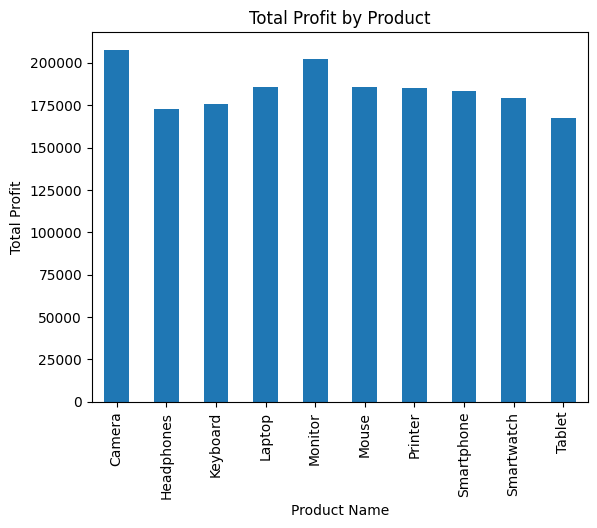

In [83]:
import matplotlib.pyplot as plt
ax=result['Total_profit'].plot(kind='bar')
ax.set_title('Total Profit by Product')
ax.set_ylabel('Total Profit')

Text(0, 0.5, 'Total Profit')

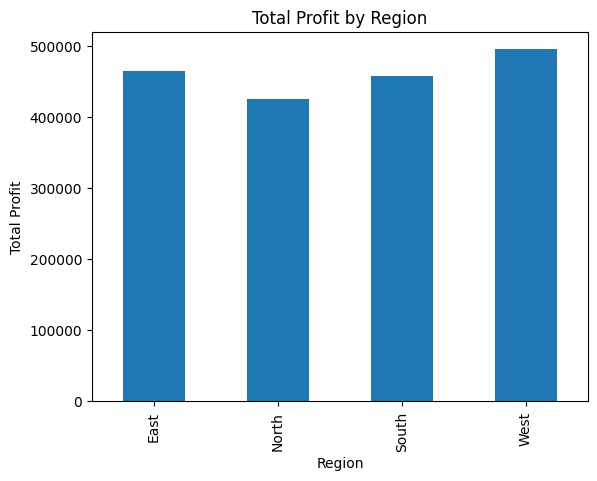

In [84]:
ax=result_2['Total_profit'].plot(kind='bar')
ax.set_title('Total Profit by Region')
ax.set_ylabel('Total Profit')

In [88]:
profit_by_region = result_1['Total_profit'].unstack()

In [90]:
profit_by_region

Region,East,North,South,West
Product Name,,,,
Camera,44880.72,51539.92,61837.30,49373.05
Headphones,44253.62,35271.58,48918.52,44034.48
Keyboard,49035.88,42854.25,43399.78,40524.77
Laptop,49799.67,47233.50,38417.23,50306.41
Monitor,41722.84,52481.85,45625.39,62198.09
Mouse,42827.57,41545.73,49179.68,52210.71
Printer,47388.14,32575.35,56246.79,49184.60
Smartphone,55295.27,33808.95,34996.69,59196.06
Smartwatch,45924.55,46774.73,40307.50,45989.03


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Camera'),
  Text(1, 0, 'Headphones'),
  Text(2, 0, 'Keyboard'),
  Text(3, 0, 'Laptop'),
  Text(4, 0, 'Monitor'),
  Text(5, 0, 'Mouse'),
  Text(6, 0, 'Printer'),
  Text(7, 0, 'Smartphone'),
  Text(8, 0, 'Smartwatch'),
  Text(9, 0, 'Tablet')])

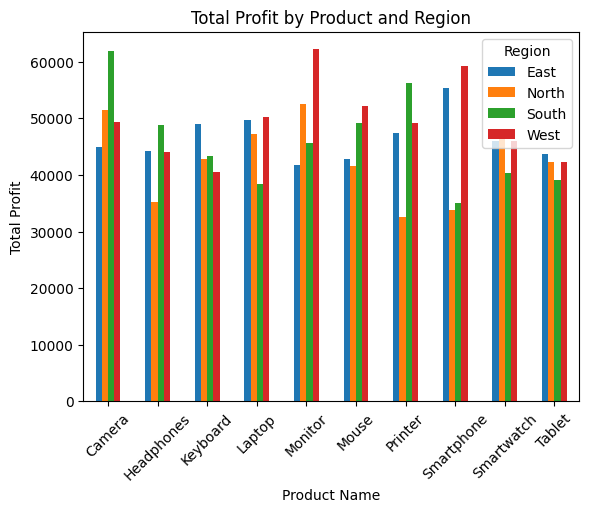

In [91]:
ax = profit_by_region.plot(kind='bar')

ax.set_title('Total Profit by Product and Region')
ax.set_xlabel('Product Name')
ax.set_ylabel('Total Profit')
plt.xticks(rotation=45)